# Electrostatics

$$\mathbf{F} = \dfrac{1}{4\pi\epsilon_0}\dfrac{q q_0}{r^2}\hat{u}$$

Where $\hat{u}$ is the unit vector from q to $q_0$.

The $4\pi$ comes from Gauss's law which states that the flux through a surface is equal to the charge inside, and represents the total solid angle. 

History:

- Coulomb used a torsion balance to evaluate forces between charges. He defined the proportionality relationship much like Newton's law of gravitation

We can define an **electrostatic field**


$$\mathbf{E(\mathbf{r})} = \dfrac{1}{4\pi\epsilon_0}\dfrac{q}{r^2}\mathbf{\hat{u}}$$

We can then extend this to multiple charges:


$$\mathbf{E(\mathbf{r})} = \dfrac{1}{4\pi\epsilon_0} \sum\limits_{l=1}^{N} \dfrac{q}{|\mathbf{r} = \mathbf{r_l}|^2}\mathbf{\hat{u_l}}$$

We may have continuous distribution of charge, with average charge density:

$\bar{\rho}_{\Delta V} = \dfrac{\Delta Q}{\Delta V}$. We can then define a function $\rho(x,y,z)$, as the limit when volume tends to 0.

Then the total charge in some volume V can be expressed as :

$Q = \iiint_V \rho(x,y,z) dV$

We can also replace the electric field equation by :

$$\mathbf{E}(\mathbf{r}) = \dfrac{1}{4\pi\epsilon_0} \iiint_V \dfrac{\rho{\mathbf{r'}\hat{\mathbf{u}(\mathbf{r'})}}}{|\mathbf{r} - \mathbf{r'}|^2}dV'$$

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def plot_vector_field(ax, x_sym, y_sym, P_expr, Q_expr, x_range=(-5, 5), y_range=(-5, 5), points=15, scale=None):
    """
    Plots a 2D SymPy vector field onto a given Matplotlib axis.
    """
    # 1. Convert SymPy expressions to NumPy functions
    F_x = sp.lambdify((x_sym, y_sym), P_expr, 'numpy')
    F_y = sp.lambdify((x_sym, y_sym), Q_expr, 'numpy')
    
    # 2. Create the coordinate grid
    x_vals = np.linspace(x_range[0], x_range[1], points)
    y_vals = np.linspace(y_range[0], y_range[1], points)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # 3. Evaluate the field at grid points
    # Handle cases where SymPy returns a constant integer (like 0 or 1) instead of an expression
    U = F_x(X, Y)
    V = F_y(X, Y)
    if isinstance(U, (int, float)): U = np.full_like(X, U)
    if isinstance(V, (int, float)): V = np.full_like(Y, V)
        
    # 4. Calculate magnitudes for coloring
    magnitudes = np.sqrt(U**2 + V**2)
    
    # 5. Plot onto the provided axes object
    quiver = ax.quiver(X, Y, U, V, magnitudes, cmap='viridis', scale=scale)
    
    # 6. Apply standard styling to the axis
    ax.set_title(f"$F = ({sp.latex(P_expr)})\\hat{{i}} + ({sp.latex(Q_expr)})\\hat{{j}}$", fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    
    return quiver


def plot_parametric_trajectory(ax, t_sym, x_expr, y_expr, t_range=(0, 2*np.pi), param_dict=None, points=100, arrow_points=10, scale=None):
    """
    Plots a 2D parametric curve x(t), y(t) and overlays its tangent (velocity) vectors.
    """
    # 1. Substitute constant parameters (like substituting w = 2) if provided
    if param_dict:
        x_expr = sp.sympify(x_expr).subs(param_dict)
        y_expr = sp.sympify(y_expr).subs(param_dict)
    else:
        x_expr = sp.sympify(x_expr)
        y_expr = sp.sympify(y_expr)

    # 2. Compute velocity vectors automatically using SymPy differentiation
    vx_expr = sp.diff(x_expr, t_sym)
    vy_expr = sp.diff(y_expr, t_sym)

    # 3. Convert SymPy math to fast NumPy functions
    f_x = sp.lambdify(t_sym, x_expr, 'numpy')
    f_y = sp.lambdify(t_sym, y_expr, 'numpy')
    f_vx = sp.lambdify(t_sym, vx_expr, 'numpy')
    f_vy = sp.lambdify(t_sym, vy_expr, 'numpy')

    # 4. Generate dense time array for a smooth curve path
    t_dense = np.linspace(t_range[0], t_range[1], points)
    X_line = f_x(t_dense)
    Y_line = f_y(t_dense)

    # Handle cases where expressions turn into constant numbers
    if isinstance(X_line, (int, float)): X_line = np.full_like(t_dense, X_line)
    if isinstance(Y_line, (int, float)): Y_line = np.full_like(t_dense, Y_line)

    # 5. Generate a smaller sample of time points specifically for the arrows
    t_arrows = np.linspace(t_range[0], t_range[1], arrow_points)
    X_arrows = f_x(t_arrows)
    Y_arrows = f_y(t_arrows)
    U_vx = f_vx(t_arrows)
    V_vy = f_vy(t_arrows)

    # Fallback checks for constant velocity outputs
    if isinstance(X_arrows, (int, float)): X_arrows = np.full_like(t_arrows, X_arrows)
    if isinstance(Y_arrows, (int, float)): Y_arrows = np.full_like(t_arrows, Y_arrows)
    if isinstance(U_vx, (int, float)): U_vx = np.full_like(t_arrows, U_vx)
    if isinstance(V_vy, (int, float)): V_vy = np.full_like(t_arrows, V_vy)

    # 6. Plot the trajectory line path
    ax.plot(X_line, Y_line, label='Trajectory', color='royalblue', lw=2)

    # 7. Add the velocity direction arrows along that path
    magnitudes = np.sqrt(U_vx**2 + V_vy**2)
    quiver = ax.quiver(X_arrows, Y_arrows, U_vx, V_vy, magnitudes, 
                       cmap='plasma', scale=scale, zorder=3, width=0.005)

    # 8. Visual styling
    ax.set_title(f"$x(t) = {sp.latex(x_expr)}$\n$y(t) = {sp.latex(y_expr)}$", fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_aspect('equal')
    
    return quiver


import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def plot_field_lines_safe(ax, x_sym, y_sym, P_expr, Q_expr, x_range=(-5, 5), y_range=(-5, 5), points=30):
    """
    Traces continuous field lines for a 2D SymPy vector field.
    Note: streamplot requires a higher density grid (points >= 30) for smooth tracing.
    """
    # 1. Convert SymPy expressions to NumPy functions
    F_x = sp.lambdify((x_sym, y_sym), P_expr, 'numpy')
    F_y = sp.lambdify((x_sym, y_sym), Q_expr, 'numpy')
    
    # 2. Create the coordinate grid (using an even number of points to avoid center singularities)
    x_vals = np.linspace(x_range[0], x_range[1], points)
    y_vals = np.linspace(y_range[0], y_range[1], points)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # 3. Evaluate variables safely
    with np.errstate(divide='ignore', invalid='ignore'):
        U = F_x(X, Y)
        V = F_y(X, Y)
    
    # 4. Clean constants and missing values
    if isinstance(U, (int, float)): U = np.full_like(X, U)
    if isinstance(V, (int, float)): V = np.full_like(Y, V)
    U = np.nan_to_num(U, nan=0.0, posinf=0.0, neginf=0.0)
    V = np.nan_to_num(V, nan=0.0, posinf=0.0, neginf=0.0)
        
    magnitudes = np.sqrt(U**2 + V**2)
    
    # 5. Plot stream lines instead of quiver arrows
    # density=1.2 controls line spacing; linewidth can map directly to field strength
    streams = ax.streamplot(X, Y, U, V, color=magnitudes, cmap='viridis', 
                            density=1.2, linewidth=1.5, arrowsize=1.2)
    
    # 6. Styling matches your existing canvas layout
    ax.set_title(f"Field Lines: $F = ({sp.latex(P_expr)})\\hat{{i}} + ({sp.latex(Q_expr)})\\hat{{j}}$", fontsize=9)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    
    return streams



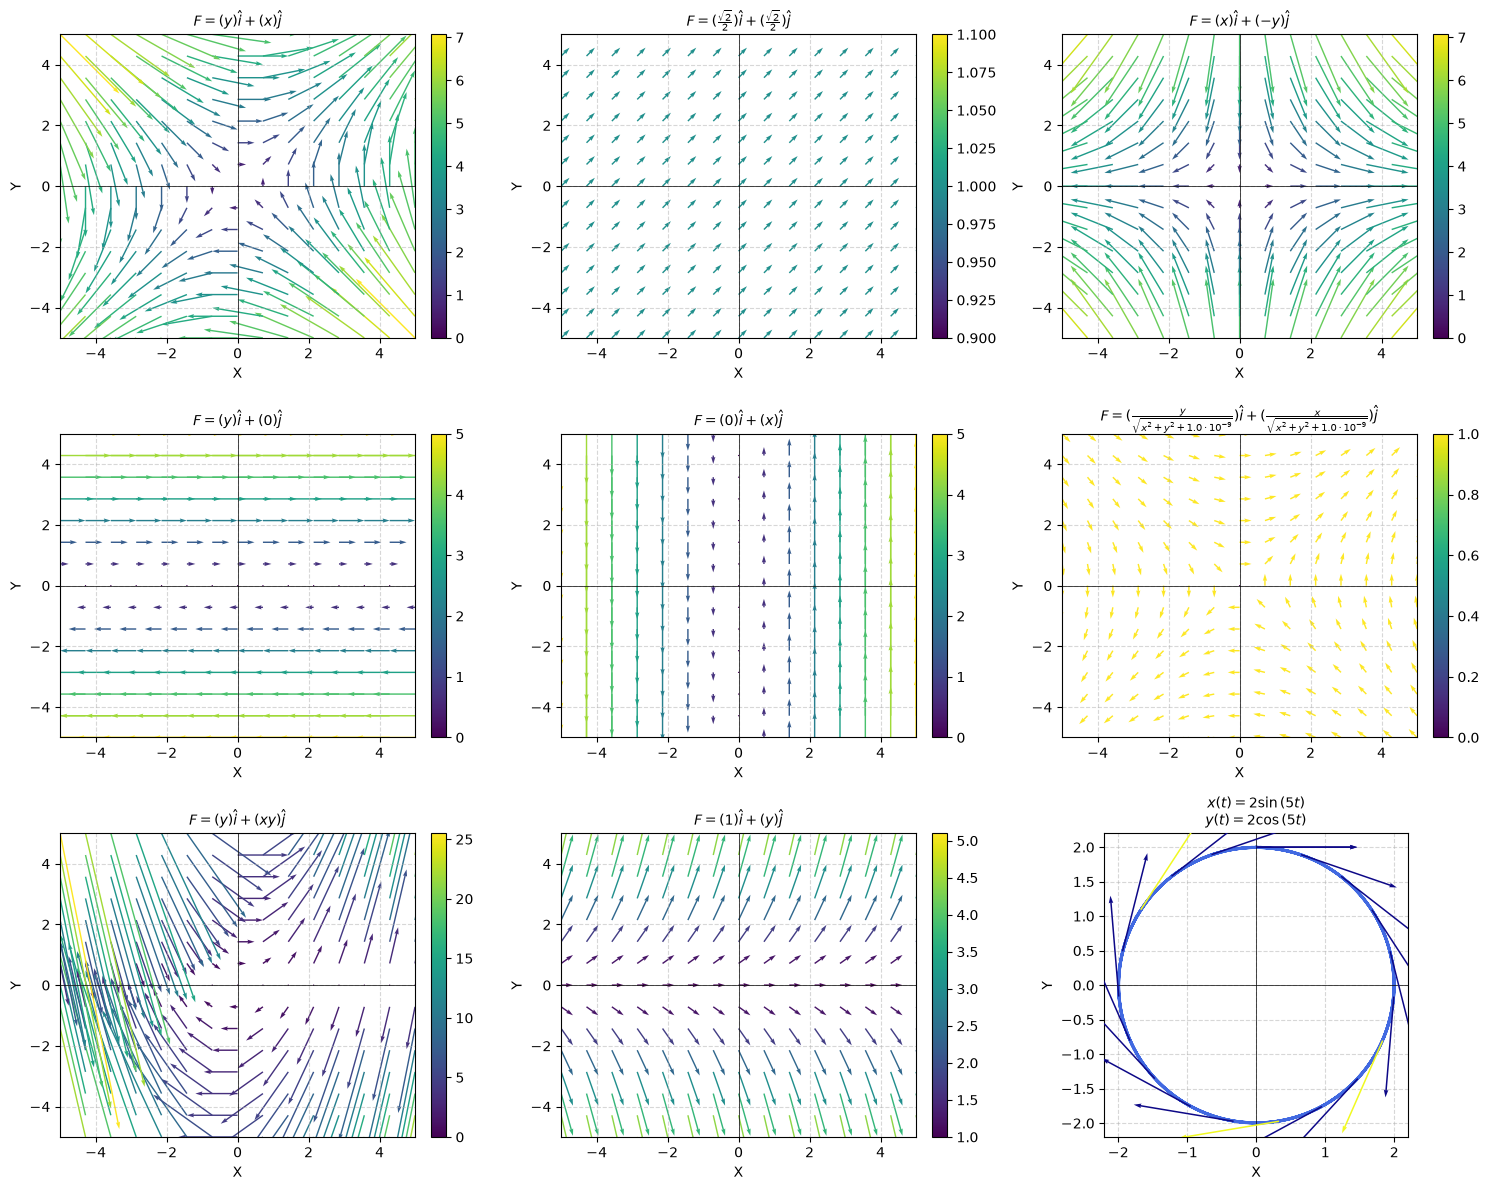

In [47]:
# Define symbols
x, y, t = sp.symbols('x y t')

# Set up your grid layout independently (1 row, 3 columns)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

# Define 3 different vector fields to compare
fields = [
    (y, x, axes[0][0]),         
    (1/sp.sqrt(2), 1/sp.sqrt(2), axes[0][1]),
    (x, -y, axes[0][2]),         
    (y, 0, axes[1][0]),         
    (0, x, axes[1][1]),
    (y/sp.sqrt(x**2 + y**2+ 1e-9), x/sp.sqrt(x**2 + y**2+ 1e-9), axes[1][2]),
    (y, x*y, axes[2][0]),         
    (1, y, axes[2][1]),         
]

# Loop through and plot each field on its designated axis
for i, (P, Q, ax) in enumerate(fields):
    q = plot_vector_field(ax, x, y, P, Q, scale=30)
    
    # Optional: Add a colorbar next to each plot
    fig.colorbar(q, ax=ax, fraction=0.046, pad=0.04)

plot_parametric_trajectory(axes[2][2], t, 2*sp.sin(5*t), 2*sp.cos(5*t), t_range=(0, 2*np.pi), points=200, arrow_points=20, scale=30)

plt.tight_layout()
plt.show()


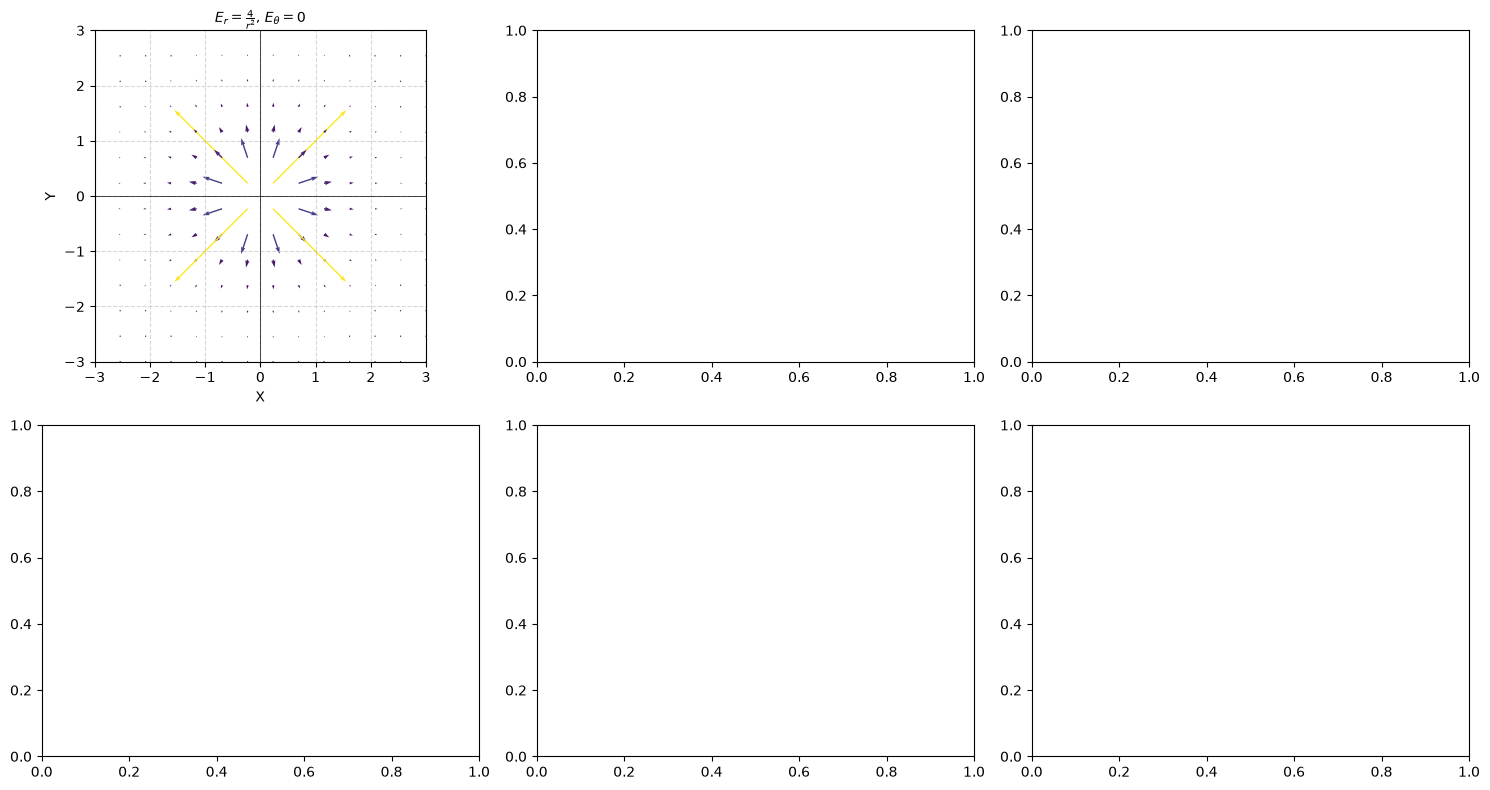

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def plot_vector_field_safe(ax, x_sym, y_sym, P_expr, Q_expr, x_range=(-5, 5), y_range=(-5, 5), points=16, scale=None):
    """
    Plots a 2D SymPy vector field safely, preventing division by zero errors.
    """
    # 1. Convert SymPy expressions to NumPy functions
    F_x = sp.lambdify((x_sym, y_sym), P_expr, 'numpy')
    F_y = sp.lambdify((x_sym, y_sym), Q_expr, 'numpy')
    
    # 2. Create the coordinate grid (using an even number of points avoids exact 0)
    x_vals = np.linspace(x_range[0], x_range[1], points)
    y_vals = np.linspace(y_range[0], y_range[1], points)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # 3. Evaluate the field safely, suppressing division-by-zero warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        U = F_x(X, Y)
        V = F_y(X, Y)
    
    # 4. Handle constant expressions (e.g., if P_expr evaluates to an int/float)
    if isinstance(U, (int, float)): U = np.full_like(X, U)
    if isinstance(V, (int, float)): V = np.full_like(Y, V)
    
    # 5. Replace NaN and Infinity values with 0.0 so Matplotlib doesn't crash
    U = np.nan_to_num(U, nan=0.0, posinf=0.0, neginf=0.0)
    V = np.nan_to_num(V, nan=0.0, posinf=0.0, neginf=0.0)
        
    # 6. Calculate magnitudes for coloring safely
    magnitudes = np.sqrt(U**2 + V**2)
    
    # 7. Plot onto the provided axes object
    quiver = ax.quiver(X, Y, U, V, magnitudes, cmap='viridis', scale=scale)
    
    # 8. Apply standard styling to the axis
    ax.set_title(f"$F = ({sp.latex(P_expr)})\\hat{{i}} + ({sp.latex(Q_expr)})\\hat{{j}}$", fontsize=9)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    
    return quiver


def plot_polar_vector_field(ax, r_sym, theta_sym, F_r_expr, F_theta_expr, **kwargs):
    """
    Transforms polar components into Cartesian expressions, 
    then passes them directly to the Cartesian plotting function.
    """
    # 1. Define standard Cartesian symbols internally for transformation
    x_internal, y_internal = sp.symbols('x_internal y_internal', real=True)
    
    # 2. Express polar variables r and theta in terms of x and y
    r_sub = sp.sqrt(x_internal**2 + y_internal**2)
    theta_sub = sp.atan2(y_internal, x_internal)
    
    # 3. Ensure inputs are SymPy expressions (converts raw 0 or 1 into SymPy types)
    F_r_expr = sp.sympify(F_r_expr)
    F_theta_expr = sp.sympify(F_theta_expr)
    
    # 4. Substitute polar coordinates into your input expressions
    Fr_xy = F_r_expr.subs({r_sym: r_sub, theta_sym: theta_sub})
    Ftheta_xy = F_theta_expr.subs({r_sym: r_sub, theta_sym: theta_sub})
    
    # 5. Transform polar vector components to Cartesian components
    P_expr = Fr_xy * sp.cos(theta_sub) - Ftheta_xy * sp.sin(theta_sub)
    Q_expr = Fr_xy * sp.sin(theta_sub) + Ftheta_xy * sp.cos(theta_sub)
    
    # 6. Delegate the actual plotting to the Cartesian function
    quiver = plot_vector_field_safe(ax, x_internal, y_internal, P_expr, Q_expr, **kwargs)
    
    # 7. Override the title to display the original polar formulas
    ax.set_title(f"$E_r = {sp.latex(F_r_expr)}$, $E_\\theta = {sp.latex(F_theta_expr)}$", fontsize=10)
    ax.set_aspect('equal') 
    
    return quiver

# ==========================================
# RUNNING THE ELECTRIC FIELD EXAMPLE
# ==========================================

# 1. Define polar symbols
r, theta = sp.symbols('r theta', positive=True)

# 2. Define the Electric Field equations (E = 1/r^2 point charge field)
F_r = 4 / r**2
F_theta = 0  # Even though this is an integer, sp.sympify() now handles it!

# 3. Create the plotting canvas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

# 4. Generate the plot
q = plot_polar_vector_field(axes[0, 0], r, theta, F_r, F_theta, x_range=(-3, 3), y_range=(-3, 3), points=14, scale=120)

# 5. Add a colorbar and display
fig.colorbar(q, ax=ax, fraction=0.046, pad=0.04, label="Field Strength")
plt.tight_layout()
plt.show()


Problem 1-3

(a): Write a formula for a vector function in 2 dimensions which is in the positive radial direction  and magnitude is 1

$$F(x,y) = \dfrac{1}{\sqrt{x^2 + y^2}}(x\hat{i} + y\hat{j})$$

(b) At angle of 45, 1/r magnitude: $$F(x,y) = \dfrac{1}{x^2 + y^2}(\cos(\pi/4)\hat{i} + \sin(\pi/4)\hat{j})$$

(c) mag: r, dir: tangential counter-clockwise: $$F(x,y) = -y\hat{i} + x \hat{j} = \sqrt{x^2 + y^2}\left( \dfrac{-y}{\sqrt{x^2 + y^2}}\hat{i} +   \dfrac{x}{\sqrt{x^2 + y^2}}\hat{i} \right) = \sqrt{x^2 + y^2}(-\sin(\theta)\hat{i} + \cos(\theta)\hat{i})$$, where $\theta$ is the angle the position vector (x,y) makes with the x-axis.

(d) $$F(x,y,z) = \dfrac{1}{\sqrt{x^2 + y^2 + z^2}}(x\hat{i} + y\hat{j} + z\hat{k})$$


Problem 1-4: r = i a cos(wt) + j b sin(wt)

How far from origin: $\sqrt{a^2\cos^2(\omega t) + b^2\sin^2(\omega t)}$

Velocity: $\dfrac{d\mathbf{r}}{dt} = -aw\sin(wt)\mathbf{\hat{i}} + bw\cos(wt)\mathbf{\hat{j}}$

Acceleration: $\dfrac{d^2\mathbf{r}}{dt^2} = -aw^2\cos(wt)\mathbf{\hat{i}} - bw^2\sin(wt)\mathbf{\hat{j}} = -aw^2\mathbf{r}$

**Problem 1-5**: Let position (on y axis) be -1 <= p <= 1

K = 1/4 pi e0

q1 = 1, at x = 1, q2 = -1 at x = -1, $r = y^2 + 1$

Vertical components cancel, horizontal components add, by symmetry, in the -y direction.

Force due to q1 = $K\dfrac{E}{\cos(\theta)} = K\dfrac{1/r^2}{1/r} = -\dfrac{K}{r^3}\hat{i}$

Total force = $-\dfrac{2K}{r^3}\hat{i}$, where $r = \sqrt{y^2 + 1}$

**Problem 1-6**: Show field line $y = y(x)$ of a vector function $\mathbf{F}(x,y) = F_x(x,y)\hat{i} + F_y(x,y)\hat{j}$ are solutions to the differential equation $\dfrac{dy}{dx} = \dfrac{F_y(x,y)}{F_x(x,y)}$

Assume y = y(x) is a solution. At a given point $P = (x_1, y_1)$, the vector is $F_x(x_1,y_1)\hat{i} + F_y(x_1,y_1)\hat{j}$. The "slope" of the vector is by definition : $\dfrac{F_y(x_1, y_1)}{F_x(x_1, y_1)}$. It follows that :

$\dfrac{dy}{dx} = \dfrac{F_y(x_1,y_1)}{F_x(x_1,y_1)}$, at P.

This is all assuming the field line exists.



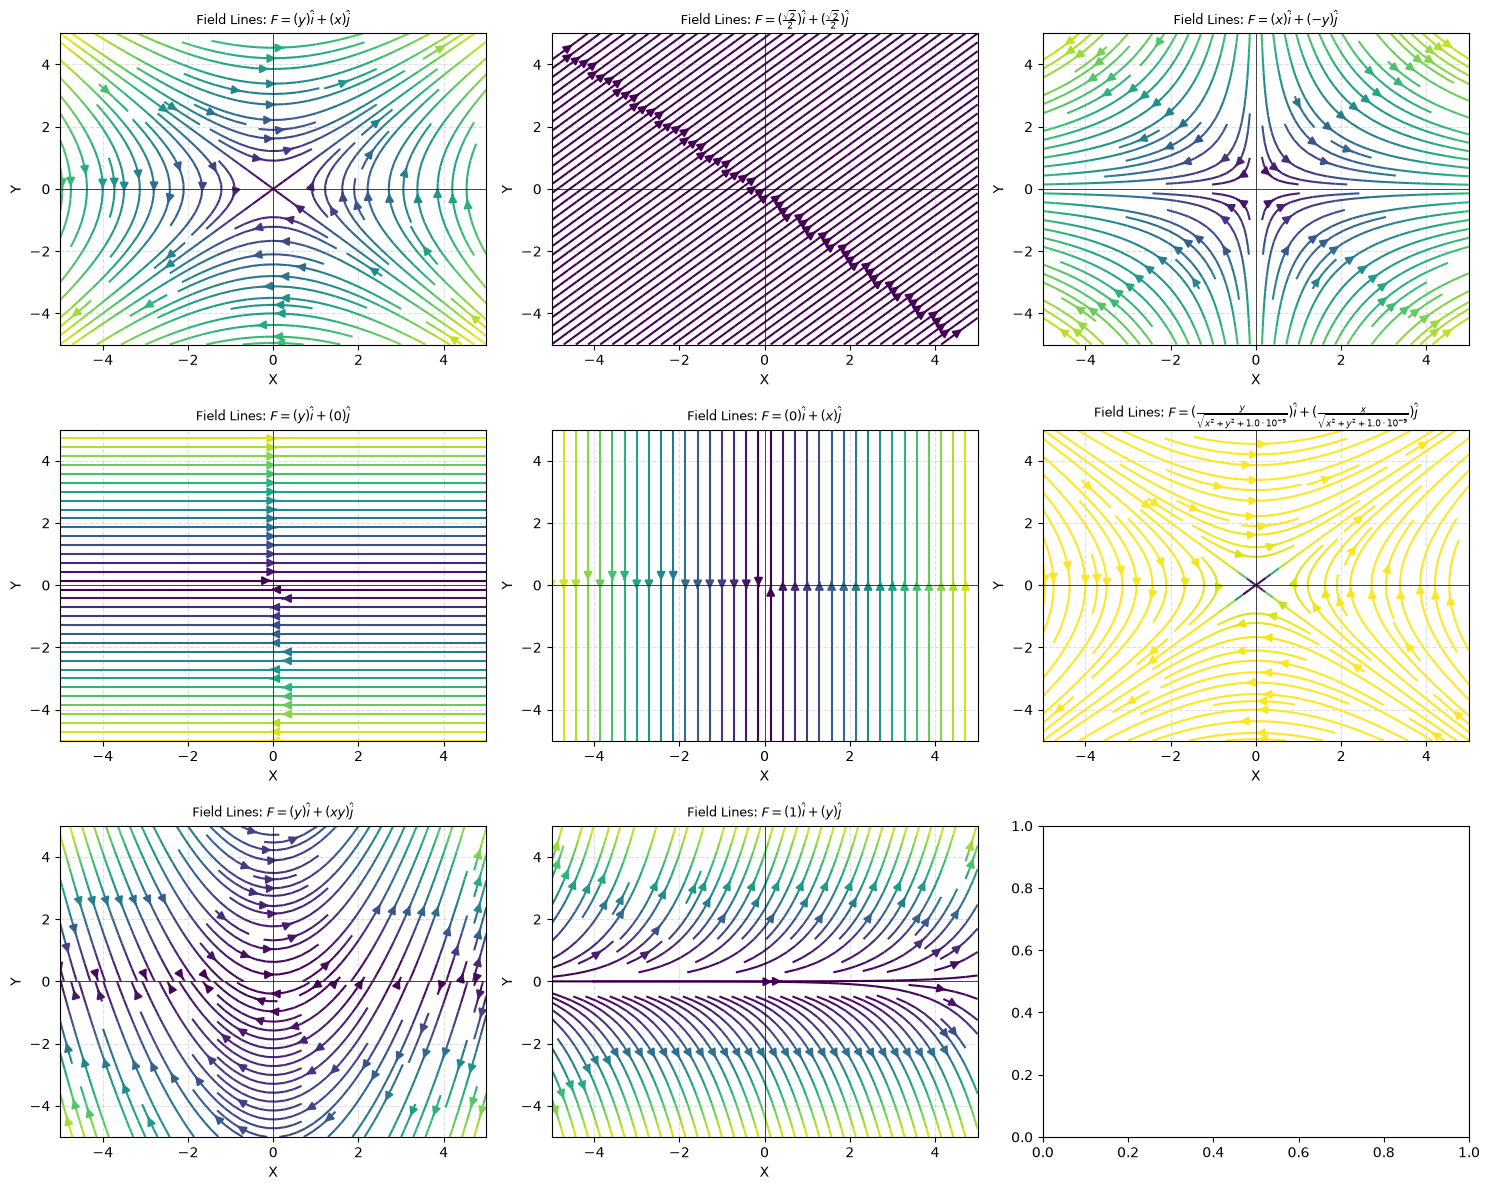

In [51]:
# Define symbols
x, y, t = sp.symbols('x y t')

# Set up your grid layout independently (1 row, 3 columns)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

# Define 3 different vector fields to compare
fields = [
    (y, x, axes[0][0]),         
    (1/sp.sqrt(2), 1/sp.sqrt(2), axes[0][1]),
    (x, -y, axes[0][2]),         
    (y, 0, axes[1][0]),         
    (0, x, axes[1][1]),
    (y/sp.sqrt(x**2 + y**2+ 1e-9), x/sp.sqrt(x**2 + y**2+ 1e-9), axes[1][2]),
    (y, x*y, axes[2][0]),         
    (1, y, axes[2][1]),         
]

# Loop through and plot each field on its designated axis
for i, (P, Q, ax) in enumerate(fields):
    q = plot_field_lines_safe(ax, x, y, P, Q)
    
plt.tight_layout()
plt.show()